# <font color='a2d2ff'> 3. Data PreProcessing, Feature Management, and Modelling #

## Data PreProcessing

This notebook focuses in the process of data cleaning, transforming and organizing the dataset to ready it for the machine learning models.

**Step 1**: Import all the needed libraries.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

import warnings
warnings.filterwarnings('ignore')

#scaling methods
# minmax
# standard
# robust
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

#filter methods
# spearman 
# chi-square
import scipy.stats as stats
from scipy.stats import chi2_contingency

#wrapper methods
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFECV, RFE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# embedded methods
from sklearn.linear_model import LassoCV

# metric
from sklearn.metrics import classification_report

from sklearn.model_selection import RepeatedStratifiedKFold

**Step 2**: Load the *learn.csv* dataset. 
A brief analysis of the dataset reveals that it already includes an `id` column, so this column will be used as the `learn` DataFrame index.

In [81]:
learn = pd.read_csv("Nata_Files/learn.csv", index_col = 0)
learn.head()

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,notes_baker,origin,oven_temperature,pastry_type,preheating_time,salt_ratio,sugar_content,vanilla_extract,quality_class
id,,,,,,,,,,,,,,,,,
1,54.0,24.0,26.0,100.4,52.0,11.0,309.0,3.2,NaN,Lisboa,NaN,Pastel Nata,207.0,42.74,22.8,5.7,KO
2,66.0,37.0,34.0,98.0,46.0,10.0,317.0,3.3,NaN,Lisboa,306.0,NaN,245.0,41.73,11.6,4.0,KO
3,41.0,30.0,19.0,99.3,53.0,10.0,130.0,3.4,NaN,Porto,121.0,NaN,186.0,75.10,20.3,7.5,OK
4,62.0,24.0,48.0,98.0,115.0,9.0,354.0,3.3,NaN,Lisboa,357.0,Pastel de Nata,186.0,46.41,73.3,4.2,OK
5,55.0,21.0,34.0,100.1,48.0,9.0,211.0,3.0,NaN,Lisboa,202.0,Pastel de nata,218.0,56.52,80.1,6.0,KO


**Step 3**: Examine the dataset with the `info()` method.

In [82]:
learn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5200 entries, 1 to 5200
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ambient_humidity   5182 non-null   float64
 1   baking_duration    5199 non-null   float64
 2   cooling_period     5199 non-null   float64
 3   cream_fat_content  5176 non-null   float64
 4   egg_temperature    5176 non-null   float64
 5   egg_yolk_count     5176 non-null   float64
 6   final_temperature  5175 non-null   float64
 7   lemon_zest_ph      5174 non-null   float64
 8   notes_baker        0 non-null      float64
 9   origin             5039 non-null   object 
 10  oven_temperature   5179 non-null   float64
 11  pastry_type        3411 non-null   object 
 12  preheating_time    5181 non-null   float64
 13  salt_ratio         5187 non-null   float64
 14  sugar_content      5178 non-null   float64
 15  vanilla_extract    5182 non-null   float64
 16  quality_class      5199 non-n

**Step 4**: Generate the dataset's statistical summary for the numerical features using the `describe()` method.

In [83]:
learn.describe()


,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,notes_baker,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract
count,5182.000000,5199.000000,5199.000000,5176.00000,5176.000000,5176.000000,5175.000000,5174.000000,0.0,5179.000000,5181.000000,5187.000000,5178.000000,5182.000000
mean,59.980316,26.979804,31.817850,98.41306,70.812403,10.498068,223.577198,3.218902,NaN,223.541031,216.413241,55.882034,54.003418,5.307159
std,11.616151,8.320079,14.427143,1.99735,35.439831,1.257709,85.258779,0.165909,NaN,84.482034,39.533116,34.867144,47.213038,1.483175
min,40.000000,14.000000,0.000000,91.90000,12.000000,8.000000,31.000000,2.700000,NaN,58.000000,114.000000,11.550000,6.000000,2.200000
25%,50.000000,21.000000,25.000000,97.10000,44.000000,10.000000,164.000000,3.100000,NaN,166.000000,192.000000,37.910000,18.000000,4.300000
50%,60.000000,25.000000,31.000000,98.40000,67.000000,10.000000,226.000000,3.200000,NaN,227.000000,209.000000,47.170000,30.000000,5.100000
75%,70.000000,30.000000,39.000000,99.80000,92.000000,11.000000,284.000000,3.300000,NaN,283.000000,231.000000,64.610000,80.675000,6.000000
max,80.000000,89.000000,105.000000,107.30000,575.000000,15.000000,722.000000,4.000000,NaN,713.000000,499.000000,640.320000,656.500000,20.800000


**Step 5**: Check class proportions of the target variable `quality_class`. By setting the parameter `normalize = True`, the result given will be the proportions of each class on the dataset, instead of the absolute counts (which is the default result of the method `value_counts`).

In [84]:
learn['quality_class'].value_counts(normalize=True)

quality_class
OK    0.635122
KO    0.364878
Name: proportion, dtype: float64

**Step 6**: Remove the duplicate entries, previously identified in Notebook 1.

In [85]:
print(f"There are {learn.duplicated().sum()} duplicate entries.")
learn.drop_duplicates(inplace=True)
print(f"After removing all duplicates, there are now {learn.duplicated().sum()} duplicates in the dataset.")

There are 2 duplicate entries.
After removing all duplicates, there are now 0 duplicates in the dataset.


**NOTE**: It is crucial to note that, since 2 rows were removed, our dataset is now composed of **5198 rows and 17 columns**. This can be checked using the `shape` attribute.

In [86]:
print(f"shape: {learn.shape}")

shape: (5198, 17)


**Step 7**: Check the dataset for missing values.

In [87]:
missing_counts = learn.isna().sum()
missing = missing_counts[missing_counts > 0].sort_values(ascending=False)
if missing.empty:
    print("No missing values detected.")
else:
    print("Missing values detected:")
    display(missing)

Missing values detected:


notes_baker          5198
pastry_type          1788
origin                161
lemon_zest_ph          26
final_temperature      25
cream_fat_content      24
egg_temperature        24
egg_yolk_count         24
sugar_content          22
oven_temperature       20
preheating_time        19
vanilla_extract        18
ambient_humidity       18
salt_ratio             13
baking_duration         1
cooling_period          1
quality_class           1
dtype: int64

**Step 8**: Drop any empty (full of missing values) or irrelevant column. This works as a Filter Method in Feature Selection, since we are removing features before any model is trained. This method consists of analysing statistical and information properties of the columns, namely evaluate its variance or if the variable provides any meaninful information.

- The column `notes_baker` is composed of missing values, meaning that it does not retain any relevant information for the model.
- The column `pastry_type` includes data inconsistencies ("pastel nata" and "pastel de nata" - which both refer to the same pastry "Pastel de Nata"). Even if this column were to be cleaned, it would not add meaningful information since our project focuses solely in Pastéis de Nata meaning the pastry type is only "Pastel de Nata". This is equivalent to removing a feature with zero variance (constant).

In [88]:
for col in ["notes_baker", "pastry_type"]:
    if col in learn.columns:
        learn = learn.drop(columns=[col])
        print(f"Removed column: {col}")
    else:
        print(f"Column '{col}' already erased.")

Removed column: notes_baker
Removed column: pastry_type


**NOTE**: It is crucial to note that, since 2 columns were removed, our dataset is now composed of **5198 rows and 15 columns**. This can be checked using the `shape` attribute.

In [89]:
print(f"shape: {learn.shape}")

shape: (5198, 15)


**Step 9**: Remove the row with the missing value in the target column `quality_class`. This row cannot be used for training since there is no label associated with that observation.

In [90]:
learn = learn.dropna(axis = 0, subset = ['quality_class'])

**NOTE**: It is crucial to note that, since 1 row was removed, our dataset is now composed of **5197 rows and 15 columns**. This can be checked using the `shape` attribute.

In [91]:
print(f"shape: {learn.shape}")

shape: (5197, 15)


**Step 10**: Using the Hold-Out method, partition the dataset into **train+validation** (`X_train_val` and `y_train_val`) and **test** (`X_test` and `y_test`). Our dataset size will then be **85% for train+val** and **15% for test**. This is done in the preprocessing stage to **avoid data leakage** (so the test set does not provide any information in the training process when imputing missing values).

In [92]:
X = learn.drop('quality_class', axis=1)
y = learn['quality_class']

In [93]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=1, stratify = y)

In [94]:
print(f"X_train_val has {len(X_train_val)} observations and X_test has {len(X_test)} obvervations.")

X_train_val has 4417 observations and X_test has 780 obvervations.


**Step 11**: Inpute the numerical columns' missing values. 

As revealed in Notebook 1, nearly half of the features of the dataset are **positively skewed**, meaning the right tail is longer than the left tail. For those cases, the median is more representative of the data than the mean, since it is less sensitive to outliers than the latter. Therefore, for **highly skewed** features (**|skewness| >= 1**) the missing values will be imputed with the value of the **median** for the respective columns. For the cases where the distributions are nearly **symmetrical** (**|skewness| < 1**), the missing values will be imputed with the **mean** value.

In [95]:
num_cols = X.select_dtypes(include=["number"]).columns

for col in num_cols:
    non_na = X_train_val[col].dropna()

    if non_na.empty:
        continue
    skew_val = non_na.skew()

    if abs(skew_val) >= 1:
        fill_value = non_na.median()
        method = "median"
    else:
        fill_value = non_na.mean()
        method = "mean"
        
    X_train_val[col].fillna(fill_value, inplace=True)
    X_test[col].fillna(fill_value, inplace=True)

    print(f"Filled '{col}' using {method}={round(fill_value, 3)} (skewness={skew_val:.2})")

Filled 'ambient_humidity' using mean=59.952 (skewness=0.024)
Filled 'baking_duration' using median=25.0 (skewness=1.6)
Filled 'cooling_period' using mean=31.952 (skewness=0.36)
Filled 'cream_fat_content' using mean=98.418 (skewness=0.0071)
Filled 'egg_temperature' using median=67.0 (skewness=1.4)
Filled 'egg_yolk_count' using mean=10.508 (skewness=0.54)
Filled 'final_temperature' using mean=223.444 (skewness=0.011)
Filled 'lemon_zest_ph' using mean=3.218 (skewness=0.34)
Filled 'oven_temperature' using mean=223.417 (skewness=-0.0029)
Filled 'preheating_time' using median=209.0 (skewness=1.7)
Filled 'salt_ratio' using median=47.005 (skewness=5.9)
Filled 'sugar_content' using median=29.4 (skewness=1.2)
Filled 'vanilla_extract' using median=5.1 (skewness=1.7)


**Step _**: Normalize the categorical variable `origin`. Strip of any unnecessary white spaces and convert to lower case.

In [96]:
X_train_val['origin'] = X_train_val['origin'].str.strip().str.lower()
X_test['origin'] = X_test['origin'].str.strip().str.lower()

**Step _:** Encode the variable `origin` so that it can be imputed.

In [97]:
# X_train_val['origin_encoded'] = X_train_val['origin'].map({'lisboa': 0, 'porto': 1})
# X_test['origin_encoded'] = X_test['origin'].map({'lisboa': 0, 'porto': 1})
# X_train_val = X_train_val.drop(columns = "origin", axis = 1)
# X_test = X_test.drop(columns = "origin", axis = 1)

se usarmos median e mean

In [98]:
X_train_origin = X_train_val[['origin']].copy()
X_test_origin = X_test[['origin']].copy()
X_train_origin['origin_encoded'] = X_train_origin['origin'].map({'lisboa': 0, 'porto': 1})
X_test_origin['origin_encoded'] = X_test_origin['origin'].map({'lisboa': 0, 'porto': 1})

**Trying to impute the values with KNN.**

se usarmos median e mean

In [99]:
knn_imputer = KNNImputer(n_neighbors=6, weights='distance')

X_train_origin_imputed = knn_imputer.fit_transform(X_train_origin[['origin_encoded']])
X_test_origin_imputed = knn_imputer.transform(X_test_origin[['origin_encoded']])

In [100]:
# knn_imputer = KNNImputer(n_neighbors=6, weights='distance')
# X_train_val_imputed = knn_imputer.fit_transform(X_train_val)
# X_test_imputed = knn_imputer.transform(X_test)
# X_train_val = pd.DataFrame(X_train_val_imputed, columns = X_train_val.columns, index = X_train_val.index)
# X_test = pd.DataFrame(X_test_imputed, columns= X_test.columns, index = X_test.index)

In [101]:
# print(X_test['origin_encoded'].unique())
# X_train_val['origin_encoded'].unique()

se usarmos median e mean

In [102]:
X_train_origin['origin_encoded'] = (X_train_origin_imputed >= 0.5).astype(int)
X_test_origin['origin_encoded'] = (X_test_origin_imputed >= 0.5).astype(int)
X_train_origin['origin'] = X_train_origin['origin_encoded'].map({0: 'lisboa', 1: 'porto'})
X_test_origin['origin'] = X_test_origin['origin_encoded'].map({0: 'lisboa', 1: 'porto'})
X_train_val['origin'] = X_train_origin['origin']
X_test['origin'] = X_test_origin['origin']

In [103]:
# X_train_val['origin_encoded'] = (X_train_val['origin_encoded'] >= 0.5).astype(int)
# X_test['origin_encoded'] =  (X_test['origin_encoded'] >= 0.5).astype(int)
# X_train_val['origin'] = X_train_val['origin_encoded'].map({0: 'lisboa', 1: 'porto'})
# X_test['origin'] = X_test['origin_encoded'].map({0: 'lisboa', 1: 'porto'})
# X_train_val = X_train_val.drop(columns='origin_encoded', axis = 1)
# X_test = X_test.drop(columns='origin_encoded', axis=1)

In the feature selection this feature gets a score of 0 in Lasso, so we decided to drop it immediately instead of treating its 936 values outside of the threshold (Since it's a %, it can't be above 100)

In [104]:
# print(len(X_train_val[X_train_val["cream_fat_content"] > 100])) # cream_fat_content is a % so >100% is impossible
# # y_train_val = y_train_val[X_train_val["cream_fat_content"] <= 100]
# # X_train_val = X_train_val[X_train_val["cream_fat_content"] <= 100]
# #X_train_val.drop('cream_fat_content', axis=1, inplace=True)
# #X_test.drop('cream_fat_content', axis=1, inplace=True)

**Step _:** Clipping the `cream_fat_content` values.

In [105]:
X_train_val['cream_fat_content'] = X_train_val['cream_fat_content'].clip(lower=0, upper=100)
X_test['cream_fat_content'] = X_test['cream_fat_content'].clip(lower=0, upper=100)

In [106]:
X_train_val.shape

(4417, 14)

**Step 11**: Removing numerical columns' outliers using the IQR range method. This method considers outliers to be any observation above Q3 + 1.5IQR and below Q1 - 1.5IQR.

In [107]:
# total = pd.Series()
# total_test = pd.Series()
# num_cols = X_train_val.select_dtypes(include=["number"]).columns

# k = 1.5
# for col in num_cols:
#     q1 = X_train_val[col].quantile(0.25)
#     q3 = X_train_val[col].quantile(0.75)
#     low_bound = q1 - k*(q3-q1)
#     high_bound = q3 + k*(q3-q1)
    
#     outliers = pd.concat([X_train_val[X_train_val[col]<low_bound][col], X_train_val[X_train_val[col]>high_bound][col]])
#     total = pd.concat([total, pd.Series(outliers.index)])
#     print(f'{col} has {outliers.count()} outliers, outside the bounds of ({low_bound: .4}, {high_bound: .4})')

#     # repeat for the test dataset
#     outliers_test = pd.concat([X_test[X_test[col]<low_bound][col], X_test[X_test[col]>high_bound][col]])
#     total_test = pd.concat([total_test, pd.Series(outliers_test.index)])

# print(f'There is a total of {len(total)} outliers, {len(total.unique())} unique rows with outliers, in the training dataset')

In [108]:
# limits = {
#     "baking_duration" : (0,45),
#     "cooling_period" : (0,80),
#     "cream_fat_content" : (90,100),
#     "egg_temperature": (0,170),
#     "egg_yolk_count": (0,15),
#     "final_temperature": (20,450),
#     "lemon_zest_ph": (2,4),
#     "oven_temperature": (20,450),
#     "preheating_time": (100,300),
#     "salt_ratio": (0,120),
#     "sugar_content": (0, 170),
#     "vanilla_extract": (2.5,8.75)
#           }

# initial_rows = len(X_train_val)

# for col, (lower, upper) in limits.items():
#     y_train_val = y_train_val[(X_train_val[col] >= lower) & (X_train_val[col] <= upper)]
#     X_train_val = X_train_val[(X_train_val[col] >= lower) & (X_train_val[col] <= upper)]

# final_rows = len(X_train_val)
# print(initial_rows, final_rows)
# print(f"Removed {initial_rows - final_rows} rows ({100*(initial_rows - final_rows)/initial_rows:.2f}%).")

Check skewness of all numerical features on the sets X_train_val and X_test

In [109]:
skewness = pd.Series(X_train_val.select_dtypes(include=[np.number]).skew().sort_values(ascending=False))
skewness1 = pd.Series(X_test.select_dtypes(include=[np.number]).skew().sort_values(ascending=False))

print("Skewness of all numerical columns:")
skew_table = pd.merge(skewness.reset_index(), skewness1.reset_index(), on='index').set_index('index')
skew_table.columns=['train skew', 'test skew']
skew_table

Skewness of all numerical columns:


,train skew,test skew
index,,
salt_ratio,5.865080,3.863033
preheating_time,1.716251,1.536553
vanilla_extract,1.703910,1.222513
baking_duration,1.567239,1.374820
egg_temperature,1.413222,0.753598
sugar_content,1.194143,2.739594
egg_yolk_count,0.543683,0.555598
cooling_period,0.360553,0.094490
lemon_zest_ph,0.343231,0.292871


Some variables are highly-skewed so we decided to add new columns with their logarithms.

In [110]:
X_train_val['sugar_content_log'] = np.log(X_train_val['sugar_content'])
X_test['sugar_content_log'] = np.log(X_test['sugar_content'])
X_train_val['salt_ratio_log'] = np.log(X_train_val['salt_ratio'])
X_test['salt_ratio_log'] = np.log(X_test['salt_ratio'])
X_train_val['baking_duration_log'] = np.log(X_train_val['baking_duration'])
X_test['baking_duration_log'] = np.log(X_test['baking_duration'])
X_train_val['preheating_time_log'] = np.log(X_train_val['preheating_time'])
X_test['preheating_time_log'] = np.log(X_test['preheating_time'])
X_train_val['vanilla_extract_log'] = np.log(X_train_val['vanilla_extract'])
X_test['vanilla_extract_log'] = np.log(X_test['vanilla_extract'])

In [111]:
skewness = pd.Series(X_train_val.iloc[:,-5:].skew().sort_values(ascending=False))
skewness1 = pd.Series(X_test.iloc[:,-5:].skew().sort_values(ascending=False))

print("Skewness of added columns:")
skew_table = pd.merge(skewness.reset_index(), skewness1.reset_index(), on='index').set_index('index')
skew_table.columns=['train skew', 'test skew']
skew_table

Skewness of added columns:


,train skew,test skew
index,,
salt_ratio_log,0.893215,0.692598
preheating_time_log,0.859538,0.817374
baking_duration_log,0.727970,0.703704
vanilla_extract_log,0.357139,0.397171
sugar_content_log,0.258157,0.174807


**Step 12**: Check that the categorical column `origin` is clean and has no missing values.

In [112]:
print(X_train_val['origin'].unique(), X_test['origin'].unique())

['lisboa' 'porto'] ['lisboa' 'porto']


In [113]:
# X_train_val['origin'] = X_train_val['origin'].str.strip().str.title()
# X_test['origin'] = X_test['origin'].str.strip().str.title()
# print(X_train_val['origin'].unique(), X_test['origin'].unique())

In [114]:
i8min, i8max, i16min, i16max, i32min, i32max, i64min, i64max = np.iinfo(np.int8).min, np.iinfo(np.int8).max, np.iinfo(np.int16).min, np.iinfo(np.int16).max, np.iinfo(np.int32).min, np.iinfo(np.int32).max, np.iinfo(np.int64).min, np.iinfo(np.int64).max
print(f'int8:[{i8min}, {i8max}]')
print(f'int16:[{i16min}, {i16max}]')
print(f'int32:[{i32min}, {i32max}]')
print(f'int64:[{i64min}, {i64max}]\n')


f16min, f16max, f32min, f32max, f64min, f64max = np.finfo(np.float16).min, np.finfo(np.float16).max, np.finfo(np.float32).min, np.finfo(np.float32).max, np.finfo(np.float64).min, np.finfo(np.float64).max
#float8 doesn't exist
print(f'float16:[{f16min}, {f16max}]')
print(f'float32:[{f32min}, {f32max}]')
print(f'float64:[{f64min}, {f64max}]')

int8:[-128, 127]
int16:[-32768, 32767]
int32:[-2147483648, 2147483647]
int64:[-9223372036854775808, 9223372036854775807]

float16:[-65504.0, 65504.0]
float32:[-3.4028234663852886e+38, 3.4028234663852886e+38]
float64:[-1.7976931348623157e+308, 1.7976931348623157e+308]


In [115]:
X_train_val.describe()

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract,sugar_content_log,salt_ratio_log,baking_duration_log,preheating_time_log,vanilla_extract_log
count,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000
mean,59.951602,26.884084,31.951777,98.175405,70.585012,10.507731,223.443585,3.217868,223.416591,216.662667,55.886057,53.363731,5.311388,3.614545,3.914099,3.252023,5.363838,1.635017
std,11.621237,8.201502,14.347183,1.633399,35.473161,1.256256,84.945351,0.165103,84.125383,39.315761,35.528048,46.145582,1.491387,0.854398,0.430883,0.272143,0.166071,0.259495
min,40.000000,14.000000,0.000000,91.900000,12.000000,8.000000,39.000000,2.700000,58.000000,114.000000,11.550000,6.000000,2.200000,1.791759,2.446685,2.639057,4.736198,0.788457
25%,50.000000,21.000000,25.000000,97.100000,44.000000,10.000000,165.000000,3.100000,167.000000,192.000000,38.000000,18.000000,4.300000,2.890372,3.637586,3.044522,5.257495,1.458615
50%,60.000000,25.000000,31.000000,98.400000,67.000000,10.000000,225.000000,3.200000,227.000000,209.000000,47.005000,29.400000,5.100000,3.380995,3.850254,3.218876,5.342334,1.629241
75%,70.000000,30.000000,39.000000,99.800000,92.000000,11.000000,283.000000,3.300000,282.000000,231.000000,64.340000,80.100000,6.000000,4.383276,4.164182,3.401197,5.442418,1.791759
max,80.000000,89.000000,105.000000,100.000000,575.000000,15.000000,722.000000,4.000000,713.000000,499.000000,640.320000,332.500000,20.800000,5.806640,6.461968,4.488636,6.212606,3.034953


Changing datatypes to use less memory

In [116]:
datatypes = {'ambient_humidity': 'int8', 'baking_duration': 'int8', 'cooling_period': 'int8', 'cream_fat_content': 'float16',
             'egg_temperature': 'int16', 'egg_yolk_count': 'int8', 'final_temperature': 'int16', 'lemon_zest_ph': 'float16', 
             'origin': 'category', 'oven_temperature': 'int16', 'preheating_time': 'int16', 'salt_ratio': 'float16', 
             'sugar_content': 'float16', 'vanilla_extract': 'float16', 'sugar_content_log': 'float16', 'salt_ratio_log': 'float16', 
             'baking_duration_log': 'float16', 'preheating_time_log': 'float16', 'vanilla_extract_log': 'float16'}
X_train_val = X_train_val.astype(datatypes)
X_test = X_test.astype(datatypes)
y_train_val = y_train_val.astype('category')
y_test = y_test.astype('category')

In [117]:
print(X_train_val.info(), y_train_val.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4417 entries, 1522 to 4139
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ambient_humidity     4417 non-null   int8    
 1   baking_duration      4417 non-null   int8    
 2   cooling_period       4417 non-null   int8    
 3   cream_fat_content    4417 non-null   float16 
 4   egg_temperature      4417 non-null   int16   
 5   egg_yolk_count       4417 non-null   int8    
 6   final_temperature    4417 non-null   int16   
 7   lemon_zest_ph        4417 non-null   float16 
 8   origin               4417 non-null   category
 9   oven_temperature     4417 non-null   int16   
 10  preheating_time      4417 non-null   int16   
 11  salt_ratio           4417 non-null   float16 
 12  sugar_content        4417 non-null   float16 
 13  vanilla_extract      4417 non-null   float16 
 14  sugar_content_log    4417 non-null   float16 
 15  salt_ratio_log       44

In [118]:
X_train_val.describe()

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract,sugar_content_log,salt_ratio_log,baking_duration_log,preheating_time_log,vanilla_extract_log
count,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.00000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000,4417.000000
mean,59.948155,26.884084,31.951777,inf,70.585012,10.505547,223.441476,3.218750,223.414988,216.662667,inf,inf,5.312500,3.615234,3.916016,3.253906,5.367188,1.635742
std,11.621377,8.201502,14.347183,1.633789,35.473161,1.256695,84.945356,0.165161,84.125387,39.315761,35.531250,46.15625,1.491211,0.854492,0.430908,0.271973,0.166016,0.259521
min,40.000000,14.000000,0.000000,91.875000,12.000000,8.000000,39.000000,2.699219,58.000000,114.000000,11.546875,6.00000,2.199219,1.791992,2.447266,2.638672,4.734375,0.788574
25%,50.000000,21.000000,25.000000,97.125000,44.000000,10.000000,165.000000,3.099609,167.000000,192.000000,38.000000,18.00000,4.300781,2.890625,3.636719,3.044922,5.257812,1.458984
50%,60.000000,25.000000,31.000000,98.375000,67.000000,10.000000,225.000000,3.199219,227.000000,209.000000,47.000000,29.40625,5.101562,3.380859,3.849609,3.218750,5.343750,1.628906
75%,70.000000,30.000000,39.000000,99.812500,92.000000,11.000000,283.000000,3.300781,282.000000,231.000000,64.312500,80.12500,6.000000,4.382812,4.164062,3.400391,5.441406,1.791992
max,80.000000,89.000000,105.000000,100.000000,575.000000,15.000000,722.000000,4.000000,713.000000,499.000000,640.500000,332.50000,20.796875,5.804688,6.460938,4.488281,6.210938,3.035156


In [119]:
X_train_val = X_train_val.drop('oven_temperature', axis = 1)
X_test = X_test.drop('oven_temperature', axis = 1)

In [120]:
#numerical_features_list = X_train_val.columns
#fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(15,30))

#for i in range(6):
    #numb_variable=numerical_features_list[i]
    #sns.histplot(data=X_train_val, x=numb_variable, ax=axes[i][0], color=sns.cubehelix_palette(start=.3, rot=-.5, n_colors=7)[i])
    #sns.cubehelix_palette(start=i*0.1, rot=-.5, as_cmap=True)
    #axes[i][0].set_xlabel(f'{numb_variable} histplot')

    #numb_variable=numerical_features_list[i]
    #sns.boxplot(data=X_train_val, x=numb_variable, y=y_train_val, ax=axes[i][1], color=sns.cubehelix_palette(start=.3, rot=-.5, n_colors=7)[i])
    #sns.cubehelix_palette(start=i*0.1, rot=-.5, as_cmap=True)
    #axes[i][1].set_xlabel(f'{numb_variable} boxplot')

    #numb_variable=numerical_features_list[i+6]
    #sns.histplot(data=X_train_val, x=numb_variable, ax=axes[i][2], color=sns.cubehelix_palette(start=.3, rot=-.1, n_colors=7)[i])
    #axes[i][2].set_xlabel(f'{numb_variable} histplot')

    #numb_variable=numerical_features_list[i+6]
    #sns.boxplot(data=X_train_val, x=numb_variable, y=y_train_val, ax=axes[i][3], color=sns.cubehelix_palette(start=.3, rot=-.1, n_colors=7)[i])
    #axes[i][3].set_xlabel(f'{numb_variable} boxplot')
#plt.tight_layout()

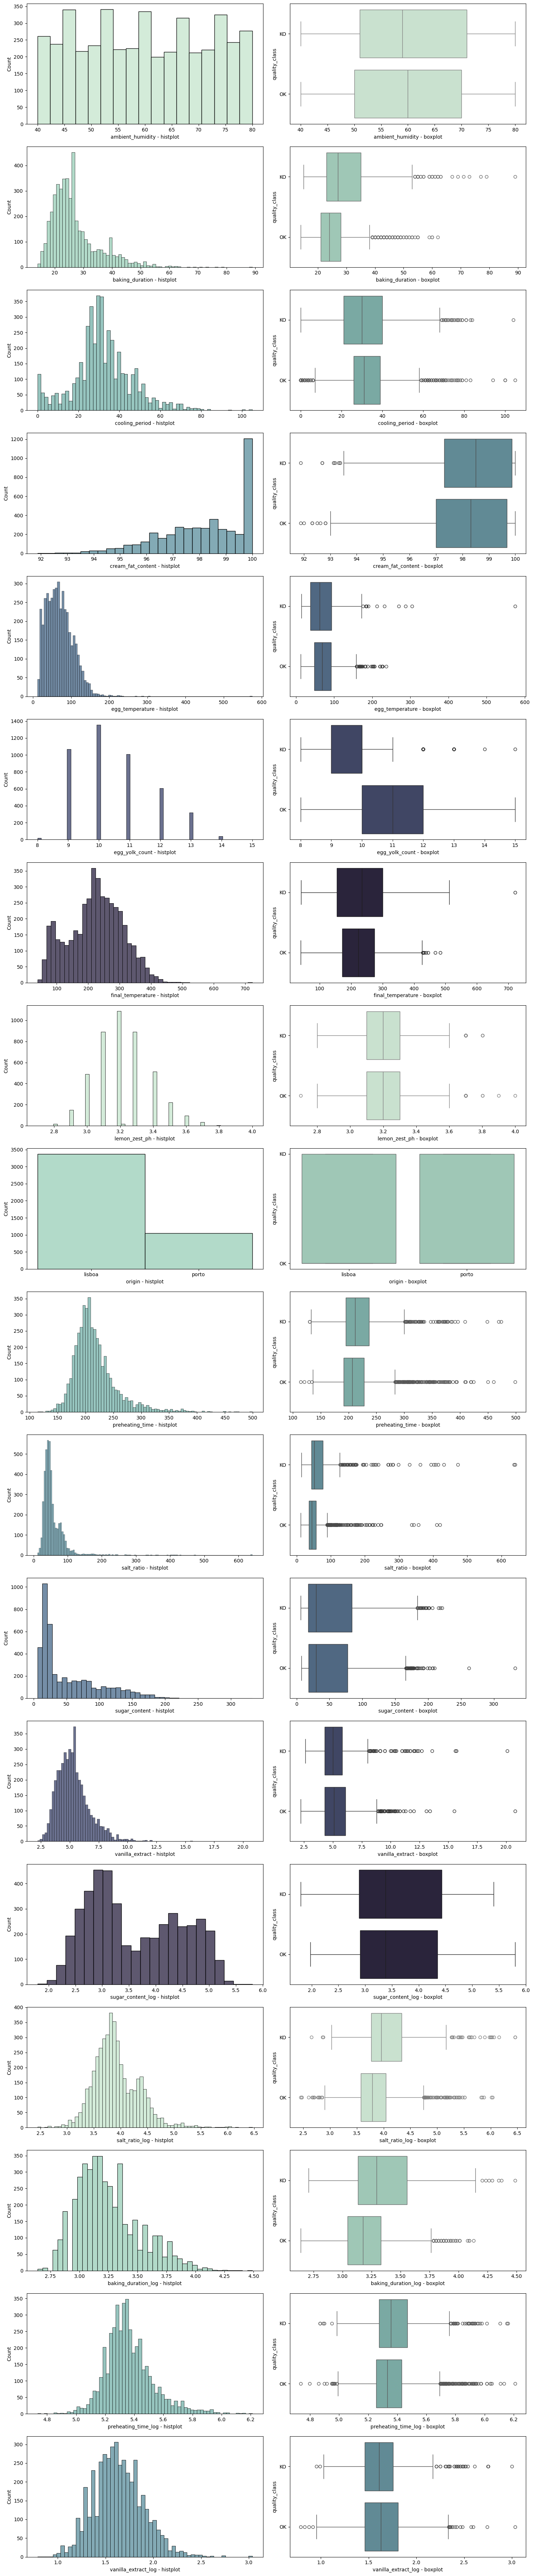

In [121]:
numerical_features_list = X_train_val.columns

fig, axes = plt.subplots(
    nrows=len(numerical_features_list),
    ncols=2,
    figsize=(15, 4*len(numerical_features_list))
)

for i, feature in enumerate(numerical_features_list):

    # Histogram
    sns.histplot(
        data=X_train_val,
        x=feature,
        ax=axes[i][0],
        color=sns.cubehelix_palette(start=.3, rot=-.5, n_colors=7)[i % 7]
    )
    axes[i][0].set_xlabel(f'{feature} - histplot')

    # Boxplot
    sns.boxplot(
        data=X_train_val,
        x=feature,
        y=y_train_val,
        ax=axes[i][1],
        color=sns.cubehelix_palette(start=.3, rot=-.5, n_colors=7)[i % 7]
    )
    axes[i][1].set_xlabel(f'{feature} - boxplot')

plt.tight_layout()
plt.show()

In [122]:
y_train_val

id
1522    KO
3184    KO
1101    OK
1606    KO
1446    KO
        ..
4786    OK
2586    KO
2986    OK
2856    OK
4139    OK
Name: quality_class, Length: 4417, dtype: category
Categories (2, object): ['KO', 'OK']

## 1. Preparation

This part of the project is the last step in preparing the data for modelling. Now that we have a clean dataset, this notebook's purpose is to ensure only relevant features are kept to train the model, ensuring it has the best performance possible, by dropping some of them.

**Step 2**: Import the partitioned and pre-processed datasets

In [123]:
X_train_full = X_train_val.copy() 
X_test = X_test.copy()
y_train_full = y_train_val.copy()
y_test = y_test.copy()

## 2. Feature Selection

**Step 1**: Check the numerical variables' correlation

In [124]:
def encode(train, test, zero, one):
    enc_train = train.replace(zero, 0).replace(one, 1)
    enc_test = test.replace(zero, 0).replace(one, 1)
    return enc_train, enc_test

In [125]:
# join all the train data to check if any of the independent variables are correlated with the target
encoded_y_train, encoded_y_test = encode(y_train_full, y_test, 'KO', 'OK')

all_train_n = X_train_full.drop('origin', axis=1).join(encoded_y_train)
all_train_n.head()

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,preheating_time,salt_ratio,sugar_content,vanilla_extract,sugar_content_log,salt_ratio_log,baking_duration_log,preheating_time_log,vanilla_extract_log,quality_class
id,,,,,,,,,,,,,,,,,,
1522,69,40,23,98.1875,22,11,141,3.500000,206,37.71875,11.203125,3.199219,2.416016,3.630859,3.689453,5.328125,1.163086,0
3184,50,28,33,97.0000,30,10,237,3.199219,219,40.25000,15.398438,6.800781,2.734375,3.695312,3.332031,5.390625,1.916992,0
1101,80,45,11,96.6875,22,10,86,3.199219,274,77.25000,27.593750,7.398438,3.318359,4.347656,3.806641,5.613281,2.001953,1
1606,46,54,0,98.8125,22,11,69,3.599609,196,166.12500,23.593750,5.101562,3.162109,5.113281,3.988281,5.277344,1.628906,0
1446,80,23,35,96.3125,36,10,262,3.099609,241,54.18750,10.703125,5.398438,2.371094,3.992188,3.134766,5.484375,1.686523,0


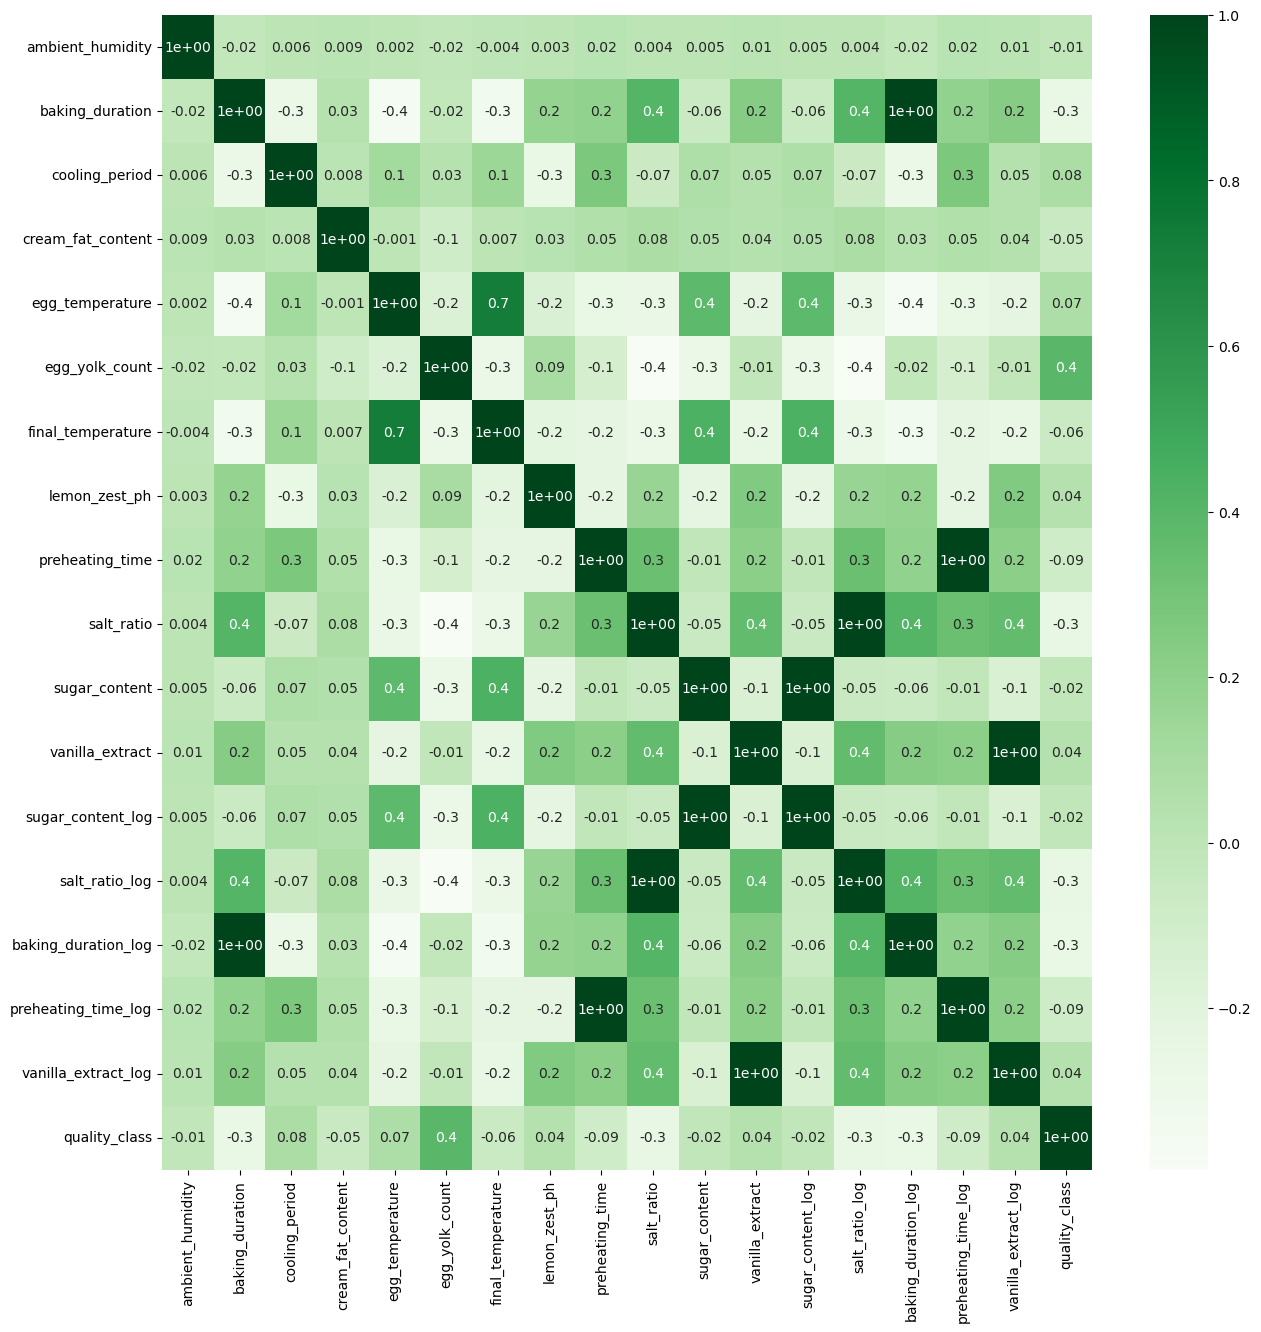

In [126]:
plt.figure(figsize=(15,15))
sns.heatmap(data = all_train_n.corr('spearman'), annot = True, cmap = plt.cm.Greens, fmt='.1')
plt.show()

In [127]:
table_spearman=[]
for var in X_train_full.drop('origin', axis=1):
    table_spearman.append('Discard')
table_spearman = pd.Series(table_spearman)

There is no independent variable highly correlated with the target. We need to use other feature selection techniques to get more insights.
There are three pairs of variables highly correlated, namely:
    - egg_temperature vs final_temperature (0.7)
    - egg_temperature vs oven_temperature (0.7)
    - final_temperature vs oven_temperature (almost 1)

We need to use other techniques of feature selection to decide which variables should we keep.

**Step 2**: Chi-squared to check the categorical variable's importance

In [128]:
encoded_y_train

id
1522    0
3184    0
1101    1
1606    0
1446    0
       ..
4786    1
2586    0
2986    1
2856    1
4139    1
Name: quality_class, Length: 4417, dtype: category
Categories (2, int64): [0, 1]

In [129]:
dfObserved = pd.crosstab(pd.Series(encoded_y_train.iloc[:]), X_train_full['origin'])
chi2, p, dof, expected = stats.chi2_contingency(dfObserved.values)
dfExpected = pd.DataFrame(expected, columns=dfObserved.columns, index = dfObserved.index)
if p<0.05:
    result="origin is IMPORTANT for Prediction"
else:
    result=f"origin is NOT an important predictor. (Discard {0} from model)"
print(result)

origin is IMPORTANT for Prediction


In [130]:
table_chi = pd.Series(['Keep'])

This time we are going to apply Recursive Feature Elimination (RFE) that will allow to select the most important features to keep. The base estimator used will be a Logistic Regression.

In [131]:
modellr = RandomForestClassifier(class_weight='balanced', random_state=1)

In [132]:
modelet = ExtraTreesClassifier(class_weight='balanced', criterion = 'gini', random_state=1)

Decide how many features we should select in the rfe. First we have to scale the data because this model is scale-sensitive

In [133]:
def scale(scaler, train, test, keep=True):
    train = train.copy()
    test = test.copy()

    origin_train = origin_test = None
    if 'origin' in train.columns:
        origin_train = train['origin']
        origin_test = test['origin']
        train.drop('origin', axis=1, inplace=True)
        test.drop('origin', axis=1, inplace=True)
        train, test = encode(train, test, 'porto', 'lisboa')

    if scaler=='RobustScaler':
        temp_scaler = RobustScaler().fit(train)
    elif scaler=='MinMaxScaler':
        temp_scaler = MinMaxScaler().fit(train)
    else:
        temp_scaler = StandardScaler().fit(train)

    # train data
    temp_train_scl = temp_scaler.transform(train) 
    temp_train_scl = pd.DataFrame(temp_train_scl, columns = train.columns, index = train.index)

    # Test data
    temp_test_scl = temp_scaler.transform(test) 
    temp_test_scl = pd.DataFrame(temp_test_scl, columns = test.columns, index = test.index)

    if keep and origin_train is not None:
        temp_train_scl['origin'] = origin_train
        temp_test_scl['origin'] = origin_test

    return temp_train_scl, temp_test_scl

In [134]:
# Number of features
nof_list=np.arange(1,19)
high_score=0
# Variable to store the optimum features
nof=0           
score_list =[]

# scale the data 
temp_X_train_n_scl, temp_X_test_n_scl = scale('RobustScaler', X_train_full, X_test, False)

for n in range(len(nof_list)):
    rfe = RFE(modelet,n_features_to_select = nof_list[n])
    X_train_rfe = rfe.fit_transform(temp_X_train_n_scl,y_train_full)
    X_val_rfe = rfe.transform(temp_X_test_n_scl)

    modelet.fit(X_train_rfe,y_train_full)
    
    score = modelet.score(X_val_rfe,y_test)
    score_list.append(score)
    #print(f"Score with {nof_list[n]} features: {score:.5f}")
    
    if(score>high_score):
        high_score = score
        nof = nof_list[n]
        best_rfe = rfe

print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))
selected_features = temp_X_test_n_scl.columns[best_rfe.support_]
print("Selected features for highest score:")
print(selected_features)

Optimum number of features: 7
Score with 7 features: 0.801282
Selected features for highest score:
Index(['egg_temperature', 'egg_yolk_count', 'final_temperature',
       'vanilla_extract', 'sugar_content_log', 'salt_ratio_log',
       'baking_duration_log'],
      dtype='object')


Create an rfe instance and initialize it with the amount of features suggested by the function above

In [135]:
rfelr = RFE(estimator=modelet, n_features_to_select=nof)

In [136]:
rfelr.fit_transform(temp_X_train_n_scl, y_train_full)

array([[-0.9375    ,  1.        , -0.7118644 , ..., -0.64659685,
        -0.4148148 ,  1.3241758 ],
       [-0.7708333 ,  0.        ,  0.10169491, ..., -0.43324608,
        -0.29259259,  0.31868133],
       [-0.9375    ,  0.        , -1.1779661 , ..., -0.04188482,
         0.9444444 ,  1.6538461 ],
       ...,
       [-0.9375    ,  2.        , -1.1355932 , ..., -0.2421466 ,
         1.0407407 ,  0.510989  ],
       [-0.47916666,  1.        , -0.3898305 , ..., -0.45549738,
        -0.4962963 , -0.11538462],
       [ 0.3125    ,  0.        , -0.11016949, ...,  0.40052357,
         0.07407407, -1.2527473 ]], shape=(4417, 7), dtype=float32)

Check the variables that were selected by RFE as the most "important" ones by calling the attribute `support_` to `rfe`.

In [137]:
print(temp_X_train_n_scl.columns)
print(rfelr.support_)
rfelr.ranking_

Index(['ambient_humidity', 'baking_duration', 'cooling_period',
       'cream_fat_content', 'egg_temperature', 'egg_yolk_count',
       'final_temperature', 'lemon_zest_ph', 'preheating_time', 'salt_ratio',
       'sugar_content', 'vanilla_extract', 'sugar_content_log',
       'salt_ratio_log', 'baking_duration_log', 'preheating_time_log',
       'vanilla_extract_log'],
      dtype='object')
[False False False False  True  True  True False False False False  True
  True  True  True False False]


array([10,  4,  2, 11,  1,  1,  1,  9,  8,  5,  7,  1,  1,  1,  1,  3,  6])

In [138]:
selected_features = pd.Series(rfelr.support_, index = temp_X_train_n_scl.columns)
print("Features to keep:\n", selected_features)

Features to keep:
 ambient_humidity       False
baking_duration        False
cooling_period         False
cream_fat_content      False
egg_temperature         True
egg_yolk_count          True
final_temperature       True
lemon_zest_ph          False
preheating_time        False
salt_ratio             False
sugar_content          False
vanilla_extract         True
sugar_content_log       True
salt_ratio_log          True
baking_duration_log     True
preheating_time_log    False
vanilla_extract_log    False
dtype: bool


In [139]:
table_rfe=[]
for var in rfelr.support_:
    if var:
        table_rfe.append('Keep')
    else:
        table_rfe.append('Discard')
table_rfe = pd.Series(table_rfe)

Because rfe is a wrapper method, the estimation depends on the supervised model that was used. The recommendation that we obtained may not be the same for other classifiers.

RFECV (RFE with Cross Validation) doesn't take as a parameter the number of selected features. The number of features selected is tuned automatically by fitting an RFE selector

In [140]:
rfecvlr = RFECV(estimator=modelet, cv=5)
rfecvlr = rfecvlr.fit(temp_X_train_n_scl, y_train_full)
# Print the optimal number of features
print("Optimal number of features: %d" % rfecvlr.n_features_)
pd.Series(rfecvlr.support_, index = temp_X_train_n_scl.columns)

Optimal number of features: 16


ambient_humidity        True
baking_duration         True
cooling_period          True
cream_fat_content      False
egg_temperature         True
egg_yolk_count          True
final_temperature       True
lemon_zest_ph           True
preheating_time         True
salt_ratio              True
sugar_content           True
vanilla_extract         True
sugar_content_log       True
salt_ratio_log          True
baking_duration_log     True
preheating_time_log     True
vanilla_extract_log     True
dtype: bool

In [141]:
table_rfecv=[]
for var in rfecvlr.support_:
    if var:
        table_rfecv.append('Keep')
    else:
        table_rfecv.append('Discard')
table_rfecv = pd.Series(table_rfecv)

Using LassoCV, create a Lasso Regression instance called `reg` and fit the data to it. We are using the scaled dataset again, because Lasso is also scale-sensitive.

In [142]:
reg = LassoCV(cv=5,random_state=1)

In [143]:
reg.fit(temp_X_train_n_scl, encoded_y_train)

LassoCV(cv=5, random_state=1)

Create a pandas Series named `coef` that will have as index the `data` columns names and the `coef_` attribute as value.

In [144]:
coef = pd.Series(reg.coef_, index = temp_X_train_n_scl.columns)

Check how many variables did Lasso pick (if the coef is different from 0) and how many variables did Lasso eliminated (if the coef is equal to 0).

In [145]:
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")
coef.abs().sort_values()

Lasso picked 13 variables and eliminated the other 4 variables


preheating_time        0.000000
baking_duration        0.000000
sugar_content          0.000000
salt_ratio             0.000000
preheating_time_log    0.001314
cream_fat_content      0.002201
ambient_humidity       0.002244
vanilla_extract        0.002879
cooling_period         0.011549
salt_ratio_log         0.016598
lemon_zest_ph          0.019912
egg_temperature        0.052265
vanilla_extract_log    0.064409
sugar_content_log      0.083947
final_temperature      0.099582
egg_yolk_count         0.140903
baking_duration_log    0.190551
dtype: float32

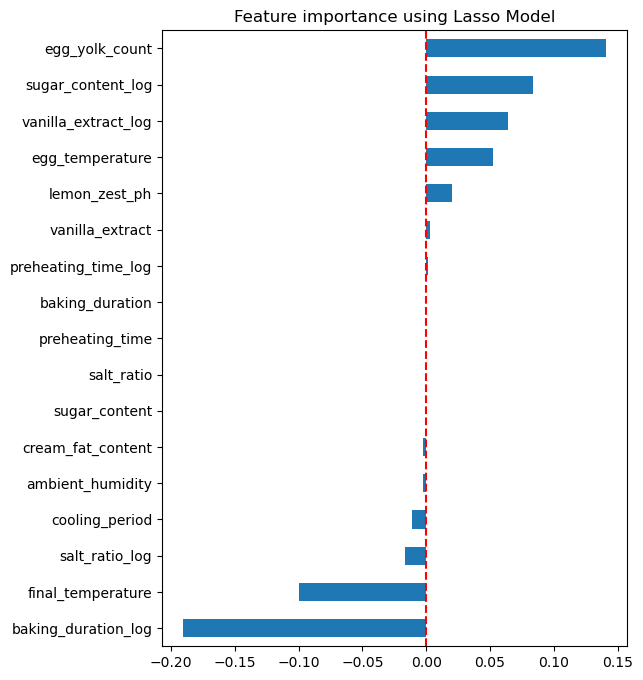

In [146]:
imp_coef = coef.sort_values()
plt.figure(figsize=(6,8))
imp_coef.plot(kind = "barh")
plt.title("Feature importance using Lasso Model")
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

In [147]:
table_lasso=[]
for var in coef.abs():
    if var>0.03:
        table_lasso.append('Keep')
    else:
        table_lasso.append('Discard')
table_lasso = pd.Series(table_lasso)

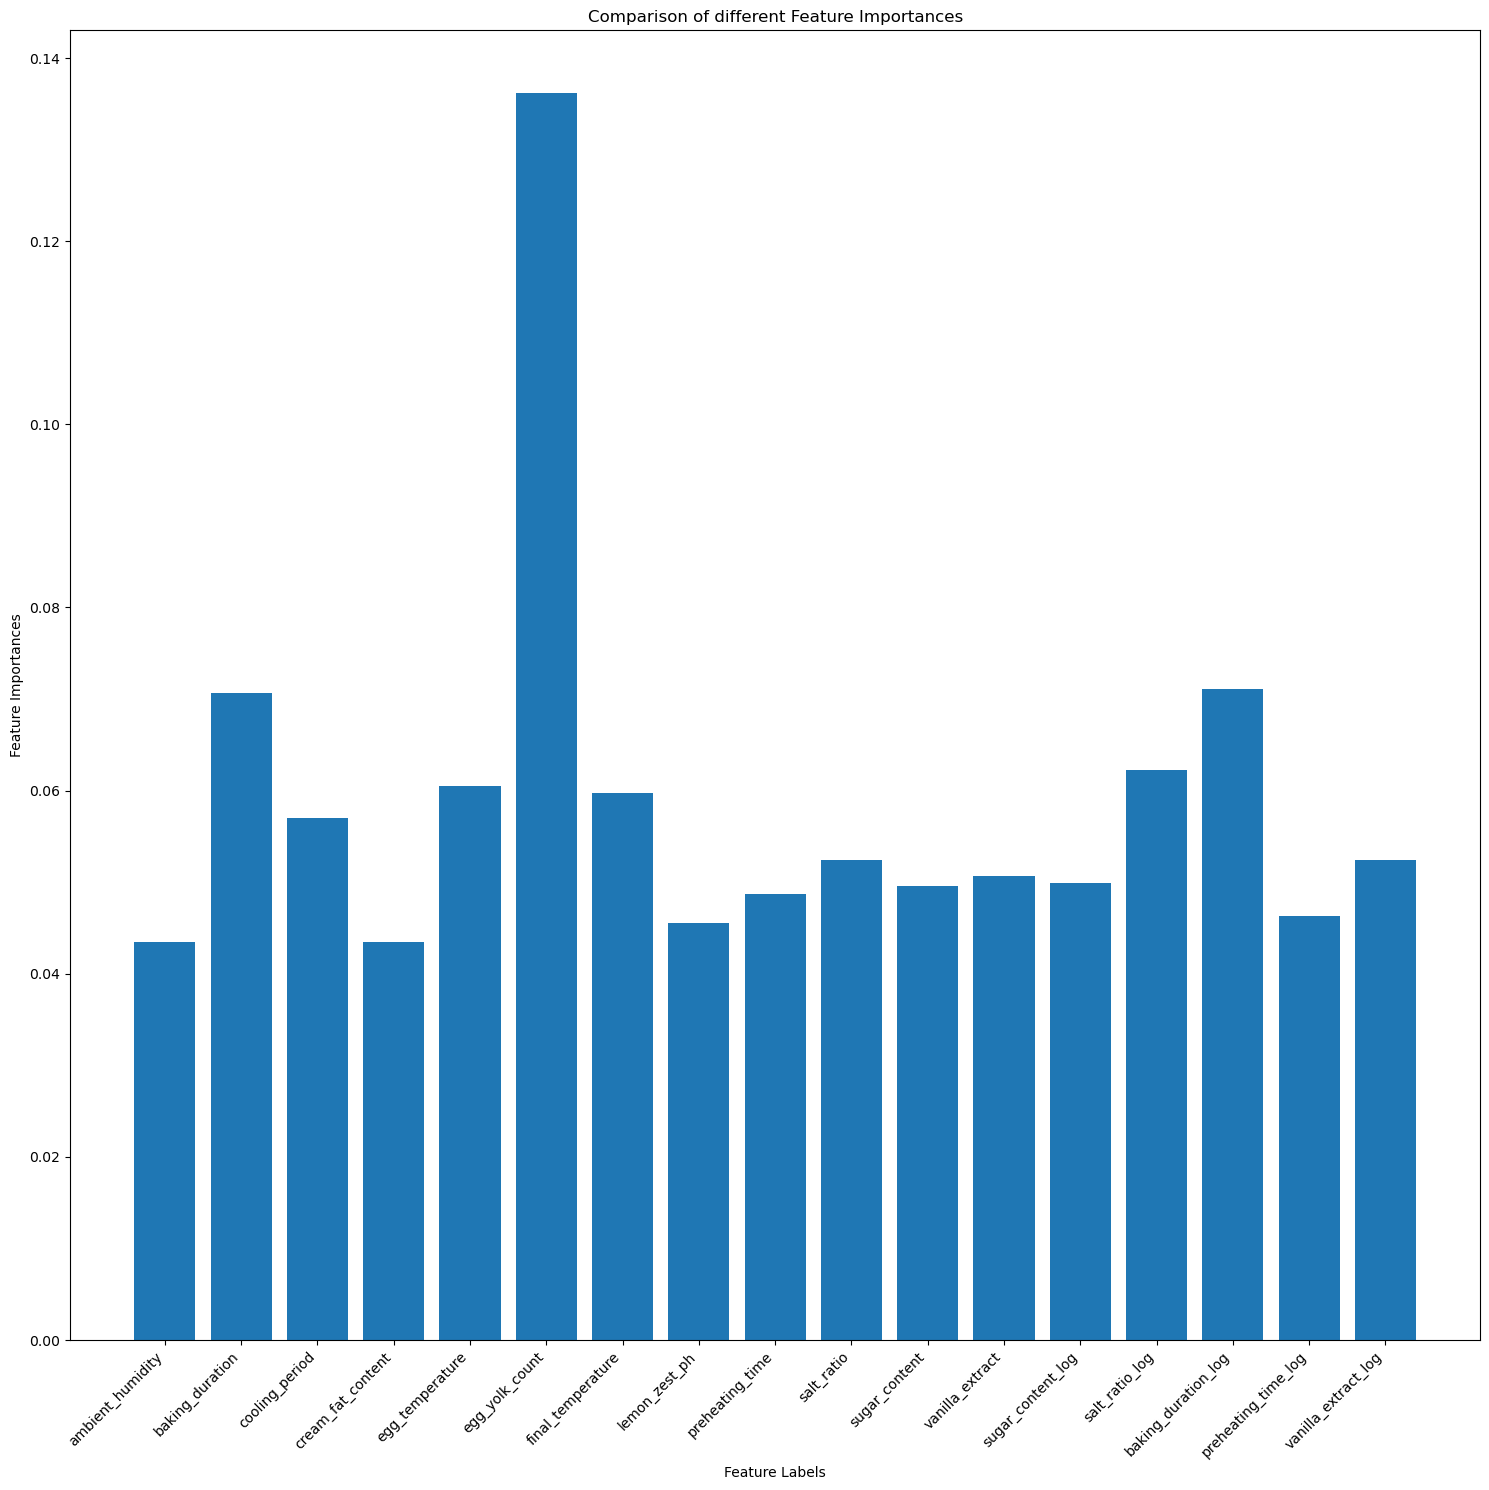

In [148]:
modelet.fit(temp_X_train_n_scl,y_train_full)
fi = modelet.feature_importances_
fig, ax = plt.subplots(figsize=(15,15))
plt.bar(temp_X_train_n_scl.columns, fi)
plt.xlabel('Feature Labels')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Feature Importances')
plt.title('Comparison of different Feature Importances')
plt.tight_layout()
plt.show()

In [149]:
threshold = 0.05  # features with importance <5% are candidates to remove
table_extra_trees = []
for var in fi:
    if var > threshold:
        table_extra_trees.append('Keep')
    else:
        table_extra_trees.append('Discard')
table_extra_trees = pd.Series(table_extra_trees)

In [150]:
n_selection = pd.DataFrame()
n_selection['Spearman'] = table_spearman
n_selection['RFE'] = table_rfe
n_selection['RFECV'] = table_rfecv
n_selection['Lasso'] = table_lasso
n_selection['ExtraTrees model'] = table_extra_trees

In [151]:
result = []
for var in range(len(n_selection)): 
    if n_selection.iloc[var].value_counts()['Discard']==5:
        result.append('Remove from the dataset')
    elif n_selection.iloc[var].value_counts()['Keep']>=4:
        result.append('Include in the dataset')
    else:
        result.append('Try with and without')
n_selection['What to do?'] = pd.Series(result)
n_selection.index = X_train_full.drop('origin', axis=1).columns


In [152]:
n_selection = pd.merge(pd.DataFrame(n_selection.reset_index()), pd.DataFrame(abs(coef).round(3).reset_index()), 'left', on='index').set_index('index')
n_selection.columns=['Spearman', 'RFE', 'RFECV', 'Lasso', 'ExtraTrees model', 'What to do?', 'abs coef score'] 
n_selection['index'] = X_train_full.columns.drop('origin')
n_selection.set_index('index', inplace=True)

In [153]:
c_selection = pd.DataFrame(table_chi)
c_selection.set_index(pd.Series(['origin']), inplace=True)
c_selection.columns=['Chi-Squared']

In [154]:
print('Numerical Data')
n_selection

Numerical Data


,Spearman,RFE,RFECV,Lasso,ExtraTrees model,What to do?,abs coef score
index,,,,,,,
ambient_humidity,Discard,Discard,Keep,Discard,Discard,Try with and without,0.002
baking_duration,Discard,Discard,Keep,Discard,Keep,Try with and without,0.000
cooling_period,Discard,Discard,Keep,Discard,Keep,Try with and without,0.012
cream_fat_content,Discard,Discard,Discard,Discard,Discard,Remove from the dataset,0.002
egg_temperature,Discard,Keep,Keep,Keep,Keep,Include in the dataset,0.052
egg_yolk_count,Discard,Keep,Keep,Keep,Keep,Include in the dataset,0.141
final_temperature,Discard,Keep,Keep,Keep,Keep,Include in the dataset,0.100
lemon_zest_ph,Discard,Discard,Keep,Discard,Discard,Try with and without,0.020
preheating_time,Discard,Discard,Keep,Discard,Discard,Try with and without,0.000


In [155]:
print('\nCategorical Data')
c_selection


Categorical Data


,Chi-Squared
origin,Keep


Comparing models

In order to get the best performance, compare models with different feature selections

In [156]:
# encoding the categorical column 
X_train_enc = X_train_full.copy()
X_test_enc = X_test.copy()
X_train_enc, X_test_enc = encode(X_train_enc, X_test_enc, 'porto', 'lisboa')

In [157]:
lst_features_to_remove = list(n_selection[n_selection['What to do?']=='Remove from the dataset'].index)
lst_more_features_to_remove = list(n_selection[n_selection['What to do?']=='Try with and without'].sort_values(by='abs coef score').index)
X_train_fs = X_train_enc.copy()
X_test_fs = X_test_enc.copy()

In [158]:
print(f'Remove: {lst_features_to_remove}\nMaybe: {lst_more_features_to_remove}')
print(f'Keep features: {list(X_train_fs.drop(lst_features_to_remove, axis=1).drop(lst_more_features_to_remove, axis=1).columns)}')

Remove: ['cream_fat_content']
Maybe: ['baking_duration', 'preheating_time', 'salt_ratio', 'sugar_content', 'preheating_time_log', 'ambient_humidity', 'vanilla_extract', 'cooling_period', 'salt_ratio_log', 'lemon_zest_ph', 'vanilla_extract_log', 'sugar_content_log']
Keep features: ['egg_temperature', 'egg_yolk_count', 'final_temperature', 'origin', 'baking_duration_log']


Create four pairs of models to compare their performances (LogisticRegression, RandomForestClassifier, BalancedRandomForestClassifier, DecisionTreeClassifier), and fit half of them to the training data with the first feature selection, and the other to the second selection

In [159]:
num_pos = np.sum(encoded_y_train == 1)
num_neg = np.sum(encoded_y_train == 0)

print(f"Number of positives: {num_pos}")
print(f"Number of negatives: {num_neg}")

Number of positives: 2806
Number of negatives: 1611


In [160]:
modellr = LogisticRegression(penalty='l2',C=1.0,solver='saga',class_weight='balanced',max_iter=1000,random_state=1)
modelrfc = RandomForestClassifier(class_weight='balanced', random_state=1, criterion= 'entropy')
modelbrfc = BalancedRandomForestClassifier(class_weight='balanced', random_state=1, criterion = 'entropy', sampling_strategy='auto')
modelknn = KNeighborsClassifier(n_neighbors=6, weights='distance', metric='minkowski', p=2)
modelet = ExtraTreesClassifier(class_weight='balanced', criterion = 'entropy', random_state=1)
modelgnb = GaussianNB(priors = [0.635122,0.364878], var_smoothing=1e-8)
modelnn = MLPClassifier(hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=32,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=30,
    validation_fraction=0.15,
    random_state=1,
    tol=1e-4)

from xgboost import XGBClassifier

modelxgb = XGBClassifier(
    n_estimators=1000,
    max_depth=6,           # depth of each tree
    learning_rate=0.05,    # smaller LR → more trees, better generalization
    subsample=0.8,         # row sampling
    colsample_bytree=0.8,  # feature sampling
    gamma=1,               # min loss reduction to split
    reg_alpha=0.01,        # L1 regularization
    reg_lambda=1,          # L2 regularization
    scale_pos_weight= num_neg / num_pos,    # adjust for class imbalance if needed
    random_state=1,
    n_jobs=-1,
    enable_categorical = True
)

from catboost import CatBoostClassifier

modelcb = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    eval_metric='F1',
    random_seed=1,
    early_stopping_rounds=50,
    verbose=100,
    cat_features=['origin'],
    scale_pos_weight = num_neg / num_pos
)


POR ALGUMA RAZAO O SCORE COM ENTROPY É MAIOR DO QUE COM GINI

In [161]:
models = [modellr, modelrfc, modelbrfc, modelknn, modelet, modelgnb, modelnn, modelxgb, modelcb]

Model evaluation with Repeated Stratified K Fold 

In [162]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
def kfold(model, xtrain, ytrain):
    scores = []
    for train_idx, val_idx in rskf.split(xtrain, ytrain):
        X_train, X_val = xtrain.iloc[train_idx], xtrain.iloc[val_idx]
        y_train, y_val = ytrain.iloc[train_idx], ytrain.iloc[val_idx]

        # scale the data
        X_train, X_val = scale('RobustScaler', X_train, X_val)

        # Train and validate the model
        model.fit(X_train, y_train)
        scores.append(model.score(X_val, y_val))
    return pd.Series(scores).mean()

In [163]:
for model in models:
    print(f'\nModel {model}')
    score = kfold(model, X_train_fs, encoded_y_train)
    print('mean score', score)


Model LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1,
                   solver='saga')
mean score 0.7235665640069076

Model RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       random_state=1)
mean score 0.778280201356612

Model BalancedRandomForestClassifier(class_weight='balanced', criterion='entropy',
                               random_state=1, sampling_strategy='auto')
mean score 0.7429646464387653

Model KNeighborsClassifier(n_neighbors=6, weights='distance')
mean score 0.7487744884520582

Model ExtraTreesClassifier(class_weight='balanced', criterion='entropy',
                     random_state=1)
mean score 0.7815269656952423

Model GaussianNB(priors=[0.635122, 0.364878], var_smoothing=1e-08)
mean score 0.6819905573519591

Model MLPClassifier(batch_size=32, early_stopping=True, hidden_layer_sizes=(128, 64),
              learning_rate='adaptive', max_iter=1000, n_iter_no_change=30,
              random_state=1

The model with the best performance is the ExtraTrees Classifier, so we're going to keep improving that one

In [85]:
# from itertools import combinations
# scores = []

# print('Model performance with all the features (including the "Remove" list)')
# score = kfold(modelet, X_train_fs, encoded_y_train)
# print('mean score', score)

# # remove the features with 'Remove' and try features to try with and without
# for var in range(len(lst_more_features_to_remove)+1):
#     for subset in combinations(lst_more_features_to_remove,var):
#         cols_removed_to_try = list(subset)
#         score = kfold(modelet, X_train_fs.drop(lst_features_to_remove, axis=1).drop(cols_removed_to_try, axis=1), encoded_y_train)

#         scores.append([cols_removed_to_try, score])

# scores_df = pd.DataFrame(scores, columns=['columns removed', 'scores'])
# scores_df['amount of maybe removed features'] = scores_df['columns removed'].apply(len)
# scores_df = scores_df[['amount of maybe removed features', 'columns removed', 'scores']]

In [164]:
# Example feature retention table (replace with your actual data structure)
# For simplicity, represent it as a dictionary with feature names and actions:
action_map = {
    "Include in the dataset": "include",
    "Remove from the dataset": "remove",
    "Try with and without": "try"
}

feature_actions = dict(
    zip(
        n_selection.index,
        n_selection['What to do?'].map(action_map)
    )
)

print(feature_actions)

# Filter initial features based on retention table
current_features = [f for f in X_train_fs.columns if feature_actions.get(f, 'try') != 'remove']

best_score = kfold(modelet, X_train_fs[current_features], encoded_y_train)

improved = True
removed_features = []

while improved:
    improved = False
    candidate_scores = []

    for feature in current_features:
        # Only consider removing features marked as 'try'
        if feature_actions.get(feature, 'try') == 'try':
            trial_features = [f for f in current_features if f != feature]
            score = kfold(modelet, X_train_fs[trial_features], encoded_y_train)
            candidate_scores.append((feature, score))

    if not candidate_scores:
        break  # No features left to try removing

    # pick the best removal
    best_feature, best_new_score = max(candidate_scores, key=lambda x: x[1])

    if best_new_score > best_score:
        best_score = best_new_score
        current_features.remove(best_feature)
        removed_features.append(best_feature)
        improved = True

print("Removed features:", removed_features)
print("Final score:", best_score)
print("Final feature set:", current_features)


{'ambient_humidity': 'try', 'baking_duration': 'try', 'cooling_period': 'try', 'cream_fat_content': 'remove', 'egg_temperature': 'include', 'egg_yolk_count': 'include', 'final_temperature': 'include', 'lemon_zest_ph': 'try', 'preheating_time': 'try', 'salt_ratio': 'try', 'sugar_content': 'try', 'vanilla_extract': 'try', 'sugar_content_log': 'try', 'salt_ratio_log': 'try', 'baking_duration_log': 'include', 'preheating_time_log': 'try', 'vanilla_extract_log': 'try'}
Removed features: ['vanilla_extract_log']
Final score: 0.7866581600843143
Final feature set: ['ambient_humidity', 'baking_duration', 'cooling_period', 'egg_temperature', 'egg_yolk_count', 'final_temperature', 'lemon_zest_ph', 'origin', 'preheating_time', 'salt_ratio', 'sugar_content', 'vanilla_extract', 'sugar_content_log', 'salt_ratio_log', 'baking_duration_log', 'preheating_time_log']


In [87]:
#pd.Series(scores).sort_values(ascending=False)
#scores_df = scores_df.sort_values(by='scores', ascending=False)
#scores_df.explode('columns removed')

The best performance was on the training set with all maybe features, so we scale and fit all the training data (including the validation subset) on that model and evaluate it on the test data

In [161]:
from sklearn.model_selection import RandomizedSearchCV

#best = scores_df['columns removed'].iloc[0]
# final_train = X_train_fs.drop(lst_features_to_remove + removed_features, axis=1)
# final_test = X_test_fs.drop(lst_features_to_remove + removed_features, axis=1)

# Features marked as 'Keep' in ExtraTrees
features_keep_n_selection = n_selection.index[n_selection['RFECV'] == 'Keep'].tolist()

# # Features in c_selection (assuming c_selection.index contains the feature names)
#features_in_c_selection = c_selection.index.tolist()

# Combine the two lists and remove duplicates
final_features = list(set(features_keep_n_selection))

# Subset the training and test sets
final_train = X_train_fs[final_features]
final_test = X_test_fs[final_features]

final_train, final_test = scale(StandardScaler, final_train, final_test)

param_distributions = {
    'n_estimators' : [1000],
    'max_depth' : [20,23],
    'min_samples_split' : [2],
    'min_samples_leaf' : [1],
    'max_features' : [0.09],
    'bootstrap' : [False],
    'class_weight' : ['balanced_subsample'],
    'criterion' : ['entropy'],
    'random_state' : [1]
}

from sklearn.model_selection import StratifiedKFold

cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=modelet,
    param_distributions=param_distributions,
    n_iter=200,         
    cv=cv,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1,
    random_state=42
)

random_search.fit(final_train, encoded_y_train)
print(random_search.best_params_)
final_model = random_search.best_estimator_
final_model.fit(final_train, encoded_y_train)


Fitting 5 folds for each of 2 candidates, totalling 10 fits
{'random_state': 1, 'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.09, 'max_depth': 23, 'criterion': 'entropy', 'class_weight': 'balanced_subsample', 'bootstrap': False}


ExtraTreesClassifier(class_weight='balanced_subsample', criterion='entropy',
                     max_depth=23, max_features=0.09, n_estimators=1000,
                     random_state=1)

In [162]:
import pandas as pd

feat_importances = pd.Series(final_model.feature_importances_, index=final_train.columns)
feat_importances.sort_values(ascending=False, inplace=True)
print(feat_importances)

egg_yolk_count         0.128616
baking_duration_log    0.084102
baking_duration        0.080088
salt_ratio_log         0.078757
salt_ratio             0.076065
final_temperature      0.073932
egg_temperature        0.073259
cooling_period         0.071882
sugar_content_log      0.067479
sugar_content          0.067112
preheating_time_log    0.066746
vanilla_extract_log    0.066258
vanilla_extract        0.065706
dtype: float64


In [928]:
# fet_imp =modelet.feature_names_in_
# importances = modelet.feature_importances_
# pd.DataFrame(fet_imp, importances)

In [ ]:
# final_train = X_train_fs.drop(lst_features_to_remove + removed_features, axis=1)
# final_test = X_test_fs.drop(lst_features_to_remove + removed_features, axis=1)
# final_train, final_test = scale(StandardScaler, final_train, final_test)
# final_model = modelet
# final_model.fit(final_train, encoded_y_train)

ExtraTreesClassifier(class_weight='balanced', criterion='entropy',
                     random_state=1)

In [163]:
final_model.predict_proba(final_train)

array([[0.95446655, 0.04553345],
       [0.79402216, 0.20597784],
       [0.20028629, 0.79971371],
       ...,
       [0.15236494, 0.84763506],
       [0.22460084, 0.77539916],
       [0.13268829, 0.86731171]], shape=(4417, 2))

In [164]:
final_model.predict_proba(final_test)

array([[0.35872429, 0.64127571],
       [0.79219545, 0.20780455],
       [0.45792948, 0.54207052],
       ...,
       [0.20127377, 0.79872623],
       [0.32223552, 0.67776448],
       [0.77874674, 0.22125326]], shape=(780, 2))

In [165]:
final_model.score(final_train, encoded_y_train)

0.999547203984605

In [166]:
final_model.score(final_test, encoded_y_test)

0.8128205128205128

In [167]:
print(classification_report(encoded_y_test, final_model.predict(final_test)))

              precision    recall  f1-score   support

           0       0.76      0.72      0.74       285
           1       0.84      0.87      0.85       495

    accuracy                           0.81       780
   macro avg       0.80      0.79      0.80       780
weighted avg       0.81      0.81      0.81       780



In [424]:
# param_distributions = {
#     'n_estimators': [500],
#     'max_depth': [15, 20, 25],
#     'min_samples_split': [15, 20, 25],
#     'min_samples_leaf': [4, 6, 8],
#     'max_features': ['sqrt']
# }
#  Fitting 5 folds for each of 27 candidates, totalling 135 fits
# {'n_estimators': 500, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': 25}
# Train: 0.8888302086083971, test: 0.7846153846153846

# param_distributions = {
#     'n_estimators': [500],
#     'max_depth': [15, 20],
#     'min_samples_split': [10, 15],
#     'min_samples_leaf': [4, 6],
#     'max_features': ['sqrt'],
#     'bootstrap' : [True]
# }
# Fitting 5 folds for each of 8 candidates, totalling 40 fits
# {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True} 
# Train: 0.9284393979403222, Test: 0.7884615384615384

# param_distributions = {
#     'n_estimators': [500],
#     'max_depth': [15, 18],
#     'min_samples_split': [11, 16],
#     'min_samples_leaf': [4, 5],
#     'max_features': ['sqrt'],
#     'bootstrap' : [True]
# }
# Fitting 5 folds for each of 8 candidates, totalling 40 fits
# {'n_estimators': 500, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': True} 
# Train: 0.9186691312384473, Test: 0.791025641025641

#param_distributions = {
#    'n_estimators': [1500],
#    'max_depth': [6],
#    'min_samples_split': [10],
#    'min_samples_leaf': [4],
#    'max_features': ['sqrt'],
#    'bootstrap' : [True],
#    'max_samples': [0.9]
#}
#Train: 0.7866385001320306
#Test: 0.7615384615384615
